In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
folder_path = "/Users/sunnybhardwaj/Desktop/Project_dataset/Final/"
full_dataset = pd.read_csv(folder_path + "youtube_trending_videos_statistics.csv", dtype={'video_id': str})

In [3]:
full_dataset

,video_id,trending_status,video_duration_minutes,log_prior_trending_count,publish_day,publish_hour,log_video_duration_minutes,title_length,title_sentiment_compound,title_has_emoji,tags_count,title_tag_ratio,log_description_length,desc_links_count,desc_hashtags_count,desc_sentiment,desc_richness
0,--0zecPP2Kc,Non-Trending,4.583333,2.833213,Tuesday,2,1.719786,36,0.0000,0,9,0.000000,5.308268,0.0,2.0,-0.1027,0.009950
1,--MFuyOvrdU,Non-Trending,4.400000,1.609438,Tuesday,11,1.686399,99,0.0000,0,23,0.000000,7.833204,13.0,5.0,0.1531,0.007137
2,--Xznxew7y4,Trending,3.383333,0.693147,Sunday,5,1.477809,94,0.2500,0,18,0.000000,7.978654,1.0,0.0,0.8689,0.000343
3,--YRoepb98U,Non-Trending,23.233333,2.079442,Friday,11,3.187729,80,0.7351,0,15,0.000000,6.527958,6.0,4.0,0.8779,0.014641
4,--ZhPAv_ijE,Non-Trending,34.700000,0.693147,Thursday,9,3.575151,49,0.4588,1,33,0.000000,5.164786,1.0,2.0,0.0000,0.017241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26204,zzErfkrza40,Trending,0.583333,6.289716,Thursday,16,0.459532,63,0.0000,0,14,0.222222,7.447751,11.0,21.0,0.9371,0.018659
26205,zzF1KnfCCSg,Trending,23.233333,4.983607,Monday,14,3.187729,80,0.0000,0,21,0.000000,6.803505,7.0,7.0,0.5859,0.015556
26206,zzKV_T9ybe8,Trending,4.416667,3.555348,Friday,5,1.689481,41,0.0000,1,4,0.000000,6.502790,8.0,3.0,-0.4939,0.016517
26207,zzO7fNvq_Sw,Non-Trending,0.750000,2.397895,Wednesday,7,0.559616,84,0.0000,1,1,0.000000,1.386294,0.0,0.0,0.0000,0.000000


In [4]:
full_dataset.isnull().sum()

video_id                        0
trending_status                 0
video_duration_minutes        801
log_prior_trending_count        0
publish_day                     0
publish_hour                    0
log_video_duration_minutes    801
title_length                    0
title_sentiment_compound        0
title_has_emoji                 0
tags_count                      0
title_tag_ratio                 0
log_description_length          0
desc_links_count                0
desc_hashtags_count             0
desc_sentiment                  0
desc_richness                   0
dtype: int64

In [5]:
full_dataset.dropna(subset=['log_video_duration_minutes'], inplace=True)

In [6]:
full_dataset.isnull().sum()

video_id                      0
trending_status               0
video_duration_minutes        0
log_prior_trending_count      0
publish_day                   0
publish_hour                  0
log_video_duration_minutes    0
title_length                  0
title_sentiment_compound      0
title_has_emoji               0
tags_count                    0
title_tag_ratio               0
log_description_length        0
desc_links_count              0
desc_hashtags_count           0
desc_sentiment                0
desc_richness                 0
dtype: int64

In [7]:
full_dataset.shape

(25408, 17)

In [8]:
#Binary encoding the target column
full_dataset['is_trending'] = full_dataset['trending_status'].map({
    'Trending': 1,
    'Non-Trending': 0
})

In [9]:
full_dataset['is_trending'].unique()

array([0, 1])

In [10]:
full_dataset.drop(columns=['trending_status'], inplace=True)

In [11]:
#Check if this step is really needed, otherwise delete this column as not getting used in further steps
#Separating the 'video_id' in a separate dataframe as it is a non feature column, will join it with the rest of the data at the end
video_ids = full_dataset[['video_id']].copy()

# Drop video_id from main dataset before train/test split
full_dataset = full_dataset.drop(columns=['video_id'])


In [12]:
video_ids.head()

,video_id
0,--0zecPP2Kc
1,--MFuyOvrdU
2,--Xznxew7y4
3,--YRoepb98U
4,--ZhPAv_ijE


In [13]:
#Split the data into Train, Validation and Test datasets
X = full_dataset.drop(columns=['is_trending'])  #Features
y = full_dataset['is_trending']                  #Target

#First split the data into train+val and test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, 
    test_size=0.2,       #20% test, 80% train
    random_state=42,     #For reproducibility
    stratify=y           #Keeps class proportions the same in train/test
)

# Then split train+val data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

In [14]:
#One-hot encoding of Categorical columns
categorical_cols = ['publish_day']

#Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

#Fit encoder on train categorical data
encoder.fit(X_train[categorical_cols])

# Transform train, val, and test
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_val_encoded = encoder.transform(X_val[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

#Convert encoded arrays to DataFrames with proper column names
encoded_cols = encoder.get_feature_names_out(categorical_cols)

full_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
full_val_encoded = pd.DataFrame(X_val_encoded, columns=encoded_cols, index=X_val.index)
full_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

#Drop original categorical columns and join encoded columns
X_train = X_train.drop(columns=categorical_cols).join(full_train_encoded)
X_val = X_val.drop(columns=categorical_cols).join(full_val_encoded)
X_test = X_test.drop(columns=categorical_cols).join(full_test_encoded)

In [15]:
X_train

,video_duration_minutes,log_prior_trending_count,publish_hour,log_video_duration_minutes,title_length,title_sentiment_compound,title_has_emoji,tags_count,title_tag_ratio,log_description_length,...,desc_hashtags_count,desc_sentiment,desc_richness,publish_day_Friday,publish_day_Monday,publish_day_Saturday,publish_day_Sunday,publish_day_Thursday,publish_day_Tuesday,publish_day_Wednesday
25923,10.366667,4.897840,19,2.430685,46,0.0000,0,32,0.333333,6.857514,...,3.0,-0.8903,0.007368,0.0,0.0,0.0,0.0,0.0,0.0,1.0
21603,281.466667,1.386294,21,5.643561,48,0.0000,1,16,0.000000,5.541264,...,3.0,-0.5106,0.027559,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15275,22.550000,3.258097,14,3.159126,80,0.0000,0,24,0.000000,6.881411,...,7.0,0.1280,0.015416,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14945,0.900000,1.791759,8,0.641854,85,0.4003,0,24,0.000000,5.252273,...,16.0,0.5859,0.084211,0.0,0.0,0.0,1.0,0.0,0.0,0.0
16208,3.383333,1.791759,6,1.477809,100,0.0000,0,25,0.066667,7.676474,...,31.0,-0.4898,0.016234,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11724,3.483333,1.609438,13,1.500367,55,0.6369,0,27,0.000000,7.422374,...,0.0,0.9360,0.004785,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3021,0.900000,2.564949,10,0.641854,76,0.0000,0,14,0.000000,6.375025,...,13.0,0.4215,0.032423,0.0,0.0,1.0,0.0,0.0,0.0,0.0
24262,41.366667,1.609438,12,3.746362,98,0.0000,0,20,0.071429,7.857094,...,11.0,0.4929,0.011614,0.0,0.0,0.0,0.0,0.0,1.0,0.0
21018,10.400000,3.784190,16,2.433613,46,0.0000,0,32,0.333333,7.061334,...,3.0,-0.8313,0.006009,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [16]:
#Cyclical encoding of Publish Hour
def cyclical_encode_hour(df, col='publish_hour'):
    max_hour = 23  #max value in hour (0-23)
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / (max_hour + 1))
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / (max_hour + 1))
    df = df.drop(columns=[col])
    return df

# Apply to train, val, test
X_train = cyclical_encode_hour(X_train, 'publish_hour')
X_val = cyclical_encode_hour(X_val, 'publish_hour')
X_test = cyclical_encode_hour(X_test, 'publish_hour')

In [17]:
X_train

,video_duration_minutes,log_prior_trending_count,log_video_duration_minutes,title_length,title_sentiment_compound,title_has_emoji,tags_count,title_tag_ratio,log_description_length,desc_links_count,...,desc_richness,publish_day_Friday,publish_day_Monday,publish_day_Saturday,publish_day_Sunday,publish_day_Thursday,publish_day_Tuesday,publish_day_Wednesday,publish_hour_sin,publish_hour_cos
25923,10.366667,4.897840,2.430685,46,0.0000,0,32,0.333333,6.857514,4.0,...,0.007368,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-9.659258e-01,2.588190e-01
21603,281.466667,1.386294,5.643561,48,0.0000,1,16,0.000000,5.541264,4.0,...,0.027559,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-7.071068e-01,7.071068e-01
15275,22.550000,3.258097,3.159126,80,0.0000,0,24,0.000000,6.881411,8.0,...,0.015416,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-5.000000e-01,-8.660254e-01
14945,0.900000,1.791759,0.641854,85,0.4003,0,24,0.000000,5.252273,0.0,...,0.084211,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.660254e-01,-5.000000e-01
16208,3.383333,1.791759,1.477809,100,0.0000,0,25,0.066667,7.676474,4.0,...,0.016234,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.000000e+00,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11724,3.483333,1.609438,1.500367,55,0.6369,0,27,0.000000,7.422374,8.0,...,0.004785,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.588190e-01,-9.659258e-01
3021,0.900000,2.564949,0.641854,76,0.0000,0,14,0.000000,6.375025,6.0,...,0.032423,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.000000e-01,-8.660254e-01
24262,41.366667,1.609438,3.746362,98,0.0000,0,20,0.071429,7.857094,19.0,...,0.011614,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.224647e-16,-1.000000e+00
21018,10.400000,3.784190,2.433613,46,0.0000,0,32,0.333333,7.061334,4.0,...,0.006009,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-8.660254e-01,-5.000000e-01


In [18]:
X_train.columns

Index(['video_duration_minutes', 'log_prior_trending_count',
       'log_video_duration_minutes', 'title_length',
       'title_sentiment_compound', 'title_has_emoji', 'tags_count',
       'title_tag_ratio', 'log_description_length', 'desc_links_count',
       'desc_hashtags_count', 'desc_sentiment', 'desc_richness',
       'publish_day_Friday', 'publish_day_Monday', 'publish_day_Saturday',
       'publish_day_Sunday', 'publish_day_Thursday', 'publish_day_Tuesday',
       'publish_day_Wednesday', 'publish_hour_sin', 'publish_hour_cos'],
      dtype='object')

In [19]:
#Scaling the numeric features (required for logistic regression)
scale_cols = ['video_duration_minutes',
    'title_sentiment_compound',
    'desc_sentiment',
    'title_length',
    'title_tag_ratio',
    'tags_count',
    'desc_links_count',
    'desc_hashtags_count',
    'desc_richness',
    'log_prior_trending_count',
    'log_video_duration_minutes',
    'log_description_length'
]

scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

def add_scaled_features(df, scaler, cols):
    scaled_data = scaler.transform(df[cols])
    scaled_df = pd.DataFrame(scaled_data, columns=[c + '_scaled' for c in cols], index=df.index)
    return pd.concat([df, scaled_df], axis=1)

# Apply to all datasets
X_train = add_scaled_features(X_train, scaler, scale_cols)
X_val = add_scaled_features(X_val, scaler, scale_cols)
X_test = add_scaled_features(X_test, scaler, scale_cols)

In [20]:
X_train

,video_duration_minutes,log_prior_trending_count,log_video_duration_minutes,title_length,title_sentiment_compound,title_has_emoji,tags_count,title_tag_ratio,log_description_length,desc_links_count,...,desc_sentiment_scaled,title_length_scaled,title_tag_ratio_scaled,tags_count_scaled,desc_links_count_scaled,desc_hashtags_count_scaled,desc_richness_scaled,log_prior_trending_count_scaled,log_video_duration_minutes_scaled,log_description_length_scaled
25923,10.366667,4.897840,2.430685,46,0.0000,0,32,0.333333,6.857514,4.0,...,-2.777651,-1.147811,2.830894,1.388474,-0.110362,-0.271281,-0.372754,1.701722,0.424903,0.418797
21603,281.466667,1.386294,5.643561,48,0.0000,1,16,0.000000,5.541264,4.0,...,-1.995736,-1.060381,-0.412029,-0.040187,-0.110362,-0.271281,0.959127,-0.626326,3.155641,-0.296699
15275,22.550000,3.258097,3.159126,80,0.0000,0,24,0.000000,6.881411,8.0,...,-0.680669,0.338501,-0.412029,0.674144,0.636871,0.104302,0.158123,0.614622,1.044031,0.431788
14945,0.900000,1.791759,0.641854,85,0.4003,0,24,0.000000,5.252273,0.0,...,0.262283,0.557077,-0.412029,0.674144,-0.857594,0.949363,4.696160,-0.357515,-1.095488,-0.453790
16208,3.383333,1.791759,1.477809,100,0.0000,0,25,0.066667,7.676474,4.0,...,-1.952902,1.212803,0.236556,0.763435,-0.110362,2.357799,0.212051,-0.357515,-0.384980,0.863973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11724,3.483333,1.609438,1.500367,55,0.6369,0,27,0.000000,7.422374,8.0,...,0.983243,-0.754375,-0.412029,0.942018,0.636871,-0.552968,-0.543191,-0.478389,-0.365807,0.725848
3021,0.900000,2.564949,0.641854,76,0.0000,0,14,0.000000,6.375025,6.0,...,-0.076265,0.163641,-0.412029,-0.218769,0.263255,0.667676,1.279993,0.155086,-1.095488,0.156523
24262,41.366667,1.609438,3.746362,98,0.0000,0,20,0.071429,7.857094,19.0,...,0.070769,1.125373,0.282883,0.316979,2.691760,0.479885,-0.092667,-0.478389,1.543144,0.962156
21018,10.400000,3.784190,2.433613,46,0.0000,0,32,0.333333,7.061334,4.0,...,-2.656152,-1.147811,2.830894,1.388474,-0.110362,-0.271281,-0.462456,0.963406,0.427392,0.529591


In [21]:
X_train.columns

Index(['video_duration_minutes', 'log_prior_trending_count',
       'log_video_duration_minutes', 'title_length',
       'title_sentiment_compound', 'title_has_emoji', 'tags_count',
       'title_tag_ratio', 'log_description_length', 'desc_links_count',
       'desc_hashtags_count', 'desc_sentiment', 'desc_richness',
       'publish_day_Friday', 'publish_day_Monday', 'publish_day_Saturday',
       'publish_day_Sunday', 'publish_day_Thursday', 'publish_day_Tuesday',
       'publish_day_Wednesday', 'publish_hour_sin', 'publish_hour_cos',
       'video_duration_minutes_scaled', 'title_sentiment_compound_scaled',
       'desc_sentiment_scaled', 'title_length_scaled',
       'title_tag_ratio_scaled', 'tags_count_scaled',
       'desc_links_count_scaled', 'desc_hashtags_count_scaled',
       'desc_richness_scaled', 'log_prior_trending_count_scaled',
       'log_video_duration_minutes_scaled', 'log_description_length_scaled'],
      dtype='object')

In [22]:
#Columns always unscaled (common)
common_features = ['title_has_emoji', 'publish_day_Friday',
       'publish_day_Monday', 'publish_day_Saturday', 'publish_day_Sunday',
       'publish_day_Thursday', 'publish_day_Tuesday', 'publish_day_Wednesday',
       'publish_hour_sin', 'publish_hour_cos']

In [23]:
#Scaled columns for Logistic Regression (with _scaled suffix)
scaled_features = [c + '_scaled' for c in scale_cols]

In [24]:
#Features for Logistic Regression
lr_features = common_features + scaled_features

#Features for Tree-based models
tree_features = common_features + scale_cols

In [25]:
#For logistic regression (with scaled features)
X_train_lr = X_train[lr_features]
X_val_lr = X_val[lr_features]
X_test_lr = X_test[lr_features]

In [26]:
# For tree-based models (with original features)
X_train_tree = X_train[tree_features]
X_val_tree = X_val[tree_features]
X_test_tree = X_test[tree_features]

LOGISTIC REGRESSION TRAINING

In [28]:
#Logistic Regression (Basic)
lr = LogisticRegression(max_iter=1000, random_state=42)

#Fit
lr.fit(X_train_lr, y_train)

#Predict
y_val_pred = lr.predict(X_val_lr)
y_val_proba = lr.predict_proba(X_val_lr)[:,1]

#Evaluate
print(classification_report(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83      2067
           1       0.86      0.76      0.80      1999

    accuracy                           0.82      4066
   macro avg       0.82      0.82      0.82      4066
weighted avg       0.82      0.82      0.82      4066

Validation ROC AUC: 0.905208288711361


In [29]:
#Logistic Regression (with class weights balanced)
lr_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  #Adjusts weights inversely proportional to class frequency
)

#Fit
lr_balanced.fit(X_train_lr, y_train)

#Predict
y_val_pred = lr_balanced.predict(X_val_lr)
y_val_proba = lr_balanced.predict_proba(X_val_lr)[:, 1]

#Evaluate
print(classification_report(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      2067
           1       0.85      0.76      0.80      1999

    accuracy                           0.82      4066
   macro avg       0.82      0.82      0.82      4066
weighted avg       0.82      0.82      0.82      4066

Validation ROC AUC: 0.905260806503881


In [30]:
#Logistic Regression (with different c values)
#List of C values to test
C_values = [0.01, 0.1, 1, 10, 100]

for c in C_values:
    print(f"\n===== Testing C = {c} =====")
    
    #Train logistic regression with given C
    lr_tuned = LogisticRegression(C=c, max_iter=1000, random_state=42)

    #Fit
    lr_tuned.fit(X_train_lr, y_train)

    #Predict
    y_val_pred = lr_tuned.predict(X_val_lr)
    y_val_proba = lr_tuned.predict_proba(X_val_lr)[:, 1]

    #Evaluate
    print(classification_report(y_val, y_val_pred))
    print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))


===== Testing C = 0.01 =====
              precision    recall  f1-score   support

           0       0.78      0.87      0.82      2067
           1       0.85      0.75      0.80      1999

    accuracy                           0.81      4066
   macro avg       0.82      0.81      0.81      4066
weighted avg       0.82      0.81      0.81      4066

Validation ROC AUC: 0.8999753868225839

===== Testing C = 0.1 =====
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      2067
           1       0.85      0.76      0.80      1999

    accuracy                           0.82      4066
   macro avg       0.82      0.82      0.82      4066
weighted avg       0.82      0.82      0.82      4066

Validation ROC AUC: 0.9044585185674598

===== Testing C = 1 =====
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      2067
           1       0.86      0.76      0.80      1999

    accuracy      

In [31]:
#Logistic Regression (Final)
lr_final = LogisticRegression(max_iter=1000, random_state=42, C=100)

#Fit
lr_final.fit(X_train_lr, y_train)

#Predict
y_val_pred = lr_final.predict(X_val_lr)
y_val_proba = lr_final.predict_proba(X_val_lr)[:,1]

#Evaluate
print(classification_report(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83      2067
           1       0.86      0.76      0.80      1999

    accuracy                           0.82      4066
   macro avg       0.82      0.82      0.82      4066
weighted avg       0.82      0.82      0.82      4066

Validation ROC AUC: 0.9053489008655271


In [32]:
#Logistic Regression (evaluation on test set)
# Combine train + validation for final training
X_final_train_lr = pd.concat([X_train_lr, X_val_lr])
y_final_train_lr = pd.concat([y_train, y_val])

# dictionary to store results
results = []

#Fit
lr_final.fit(X_final_train_lr, y_final_train_lr)

#Predict
y_test_pred = lr_final.predict(X_test_lr)
y_test_proba = lr_final.predict_proba(X_test_lr)[:,1]

#Evaluate
print(classification_report(y_test, y_test_pred))
print("Validation ROC AUC:", roc_auc_score(y_test, y_test_proba))

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "ROC AUC": roc_auc_score(y_test, y_test_proba)
})

              precision    recall  f1-score   support

           0       0.78      0.89      0.83      2584
           1       0.87      0.74      0.80      2498

    accuracy                           0.82      5082
   macro avg       0.82      0.82      0.82      5082
weighted avg       0.82      0.82      0.82      5082

Validation ROC AUC: 0.8997561826551024


RANDOM FOREST TRAINING

In [34]:
#Ramdom Forest (Basic)
rf = RandomForestClassifier(random_state=42)

#Fit
rf.fit(X_train_tree, y_train)

#Predict
y_val_pred = rf.predict(X_val_tree)
y_val_proba = rf.predict_proba(X_val_tree)[:,1]

#Evaluate
print(classification_report(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

              precision    recall  f1-score   support

           0       0.86      0.98      0.91      2067
           1       0.97      0.83      0.89      1999

    accuracy                           0.90      4066
   macro avg       0.91      0.90      0.90      4066
weighted avg       0.91      0.90      0.90      4066

Validation ROC AUC: 0.9701564618787382


In [35]:
#Ramdom Forest (Fine-Tuned)
rf = RandomForestClassifier(random_state=42)

#Define parameter ranges
param_dist = {
    'n_estimators': [500, 1000, 2000],
    'max_depth': [None, 10, 20, 30, 50],
    'max_features' : ['sqrt', 'log2', 0.3, 0.5, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

#Randomized search with 5-fold CV
random_search = RandomizedSearchCV(
    rf, 
    param_distributions=param_dist,
    n_iter=10,                #number of random combos to try
    cv=5,                     #5-fold cross-validation
    scoring='roc_auc',        #use ROC AUC as main metric
    n_jobs=-1,                #use all CPUs
    verbose=2,                #Print detailed progess of each fold and each parameter setting
    random_state=42
)

#Fit
random_search.fit(X_train_tree, y_train)

#Evaluate
print("Best Parameters:", random_search.best_params_)
print("Best CV ROC AUC:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'n_estimators': 2000, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 50, 'bootstrap': False}
Best CV ROC AUC: 0.9717786017419


In [36]:
#Best fine-tuned Ramdom Forest Model
best_model_rf = random_search.best_estimator_

#Validation prediction
y_val_pred = best_model_rf.predict(X_val_tree)
y_val_proba = best_model_rf.predict_proba(X_val_tree)[:,1]

#Evaluation
print(classification_report(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2067
           1       0.97      0.85      0.90      1999

    accuracy                           0.91      4066
   macro avg       0.92      0.91      0.91      4066
weighted avg       0.92      0.91      0.91      4066

Validation ROC AUC: 0.9748656379471787


In [37]:
#Ramdom Forest (evaluation on test set)
# Combine train + validation for final training
X_final_train_tree = pd.concat([X_train_tree, X_val_tree])
y_final_train_tree = pd.concat([y_train, y_val])

#Fit
best_model_rf.fit(X_final_train_tree, y_final_train_tree)

#Predict
y_test_pred = best_model_rf.predict(X_test_tree)
y_test_proba = best_model_rf.predict_proba(X_test_tree)[:,1]

#Evaluate
print(classification_report(y_test, y_test_pred))
print("Validation ROC AUC:", roc_auc_score(y_test, y_test_proba))

#Append results
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "ROC AUC": roc_auc_score(y_test, y_test_proba)
})

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2584
           1       0.97      0.84      0.90      2498

    accuracy                           0.91      5082
   macro avg       0.91      0.91      0.91      5082
weighted avg       0.91      0.91      0.91      5082

Validation ROC AUC: 0.9765533014647011


XGBOOST TRAINING

In [39]:
#XGBoost (Basic)
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

#Fit
xgb_clf.fit(X_train_tree, y_train)

#Predict
y_val_pred = xgb_clf.predict(X_val_tree)
y_val_proba = xgb_clf.predict_proba(X_val_tree)[:, 1]

#Evaluate
print(classification_report(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      2067
           1       0.93      0.86      0.89      1999

    accuracy                           0.90      4066
   macro avg       0.90      0.90      0.90      4066
weighted avg       0.90      0.90      0.90      4066

Validation ROC AUC: 0.9656354543987038


In [40]:
#XGBoost (Fine-Tuned)
#XGBClassifier with base parameters
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

#Define parameter ranges
param_dist = {
    'max_depth': [5, 10, 15, 20],
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0],
    'gamma': [0, 0.1, 0.3]
}

#Randomized search with 5-fold CV
random_search_xg = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=10,             #number of parameter combinations to try
    scoring='roc_auc',     #use ROC AUC as main metric
    cv=5,                  #5-fold cross-validation
    verbose=2,             #Print detailed progess of each fold and each parameter setting
    random_state=42,
    n_jobs=-1              #use all CPUs
)

#Fit
random_search_xg.fit(X_train_tree, y_train)

#Evaluate
print("Best Parameters:", random_search_xg.best_params_)
print("Best CV ROC AUC:", random_search_xg.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 1000, 'max_depth': 15, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV ROC AUC: 0.9711270679096508


In [41]:
#Best fine-tuned XGBoost Model
best_model_xg = random_search_xg.best_estimator_

#Validation prediction
y_val_pred = best_model_xg.predict(X_val_tree)
y_val_proba = best_model_xg.predict_proba(X_val_tree)[:, 1]

##Evaluation
print(classification_report(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      2067
           1       0.94      0.88      0.91      1999

    accuracy                           0.91      4066
   macro avg       0.92      0.91      0.91      4066
weighted avg       0.92      0.91      0.91      4066

Validation ROC AUC: 0.9748183235304154


In [42]:
#XGBoost (evaluation on test set)
#Fit
best_model_xg.fit(X_final_train_tree, y_final_train_tree)

#Predict
y_test_pred = best_model_xg.predict(X_test_tree)
y_test_proba = best_model_xg.predict_proba(X_test_tree)[:,1]

#Evaluate
print(classification_report(y_test, y_test_pred))
print("Validation ROC AUC:", roc_auc_score(y_test, y_test_proba))

#Append results
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "ROC AUC": roc_auc_score(y_test, y_test_proba)
})

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      2584
           1       0.94      0.88      0.91      2498

    accuracy                           0.91      5082
   macro avg       0.92      0.91      0.91      5082
weighted avg       0.91      0.91      0.91      5082

Validation ROC AUC: 0.9749093392360948


                 Model  Accuracy  Precision   ROC AUC
0  Logistic Regression  0.817001   0.865331  0.899756
1        Random Forest  0.907910   0.965170  0.976553
2              XGBoost  0.912633   0.943054  0.974909


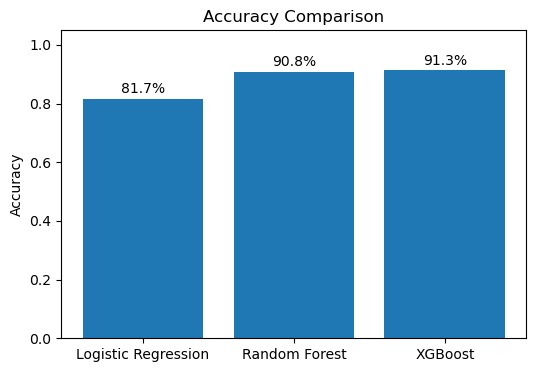

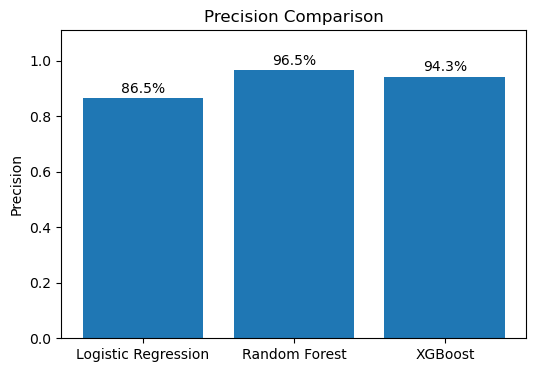

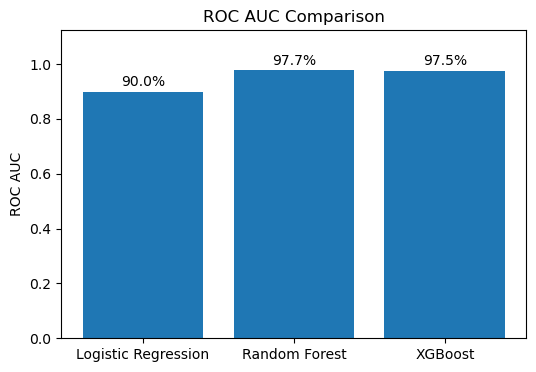

In [43]:
#Compare results of all three models
#Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

#Plot comparisons
metrics = ["Accuracy", "Precision", "ROC AUC"]

for metric in metrics:
    plt.figure(figsize=(6,4))
    bars = plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    
    #Set y-limit slightly above the max value
    plt.ylim(0, results_df[metric].max() * 1.15)
    
    #Add percentage labels slightly above the bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            height * 1.01,  # 1% above the bar height
            f"{height*100:.1f}%", 
            ha='center', va='bottom', fontsize=10, color='black'
        )
    
    plt.show()

                       feature  importance
14             title_tag_ratio    0.228217
19    log_prior_trending_count    0.157340
15                  tags_count    0.104090
20  log_video_duration_minutes    0.070239
10      video_duration_minutes    0.069742
21      log_description_length    0.067913
18               desc_richness    0.052651
12              desc_sentiment    0.041470
13                title_length    0.035163
16            desc_links_count    0.035007
17         desc_hashtags_count    0.033073
8             publish_hour_sin    0.024753
11    title_sentiment_compound    0.023337
9             publish_hour_cos    0.023196
4           publish_day_Sunday    0.007134
0              title_has_emoji    0.005392
3         publish_day_Saturday    0.004289
2           publish_day_Monday    0.004084
7        publish_day_Wednesday    0.003644
1           publish_day_Friday    0.003277
6          publish_day_Tuesday    0.003094
5         publish_day_Thursday    0.002896


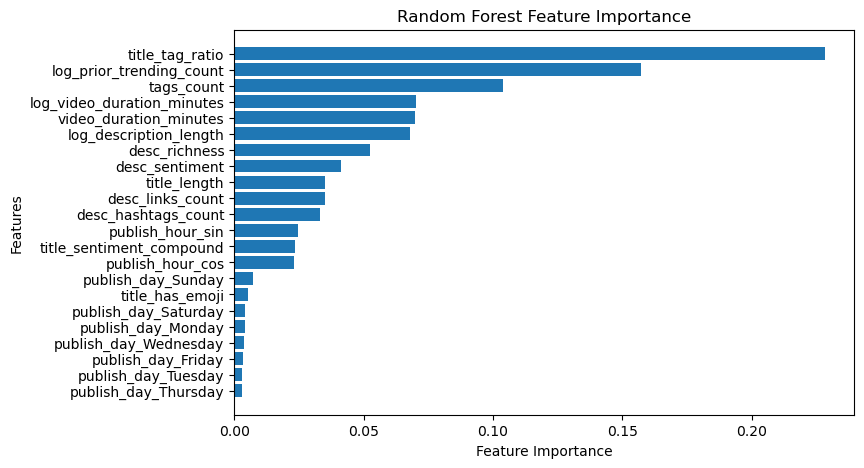

In [44]:
#Feature Importance through Random Forest
feature_importances = best_model_rf.feature_importances_
#feature_names = X_train_tree.columns[:len(feature_importances)]

try:
    feature_names = X_train_tree.columns
except AttributeError:
    feature_names = [f'feature_{i}' for i in range(len(feature_importances))]

#Make sure both arrays have same length
if len(feature_names) != len(feature_importances):
    feature_names = [f'feature_{i}' for i in range(len(feature_importances))]

#Create a DataFrame for better visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

#Sort by importance descending
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

print(feat_imp_df)

#Plot feature importances
plt.figure(figsize=(8,5))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')
plt.show()